In [1]:
# ============================================================================
# PROJETO CIN0144 - IMPLEMENTAÇÃO DO SVM COM PIPELINE DE PRÉ-PROCESSAMENTO
# ============================================================================
# Este notebook implementa o modelo SVM (Support Vector Machine) aplicado
# ao problema de previsão de evasão em cursos de ensino superior.
#
# O fluxo completo inclui:
#   1. Leitura e limpeza dos dados
#   2. Pré-processamento (missing, encoding, normalização, balanceamento)
#   3. Pipeline com diferentes combinações de técnicas
#   4. Otimização de hiperparâmetros do SVM (RandomizedSearchCV)
#   5. Validação cruzada 5-fold com threshold tuning
#   6. Avaliação e comparação de resultados
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from scipy.stats import uniform, randint


print("✅ Bibliotecas importadas.")

✅ Bibliotecas importadas.


In [2]:
# ============================================================================
# 1. CARREGAMENTO E LIMPEZA DOS DADOS
# ============================================================================

print("\n" + "=" * 70)
print(" 1. CARREGAMENTO E LIMPEZA DOS DADOS")
print("=" * 70)

# ---- Definição das colunas a serem lidas ----
COLS_CURSOS = [
    'QT_ING', 'QT_MAT', 'QT_CONC', 'QT_SIT_DESVINCULADO', 'QT_SIT_TRANCADA',
    'QT_VG_TOTAL', 'QT_VG_TOTAL_EAD', 'QT_VG_TOTAL_NOTURNO',
    'QT_ING_FEM', 'QT_ING_18_24', 'QT_INSCRITO_TOTAL',
    'QT_MAT_FINANC', 'QT_ING_FIES', 'QT_ING_PROUNIP',
    'TP_ORGANIZACAO_ACADEMICA', 'TP_REDE', 'TP_CATEGORIA_ADMINISTRATIVA',
    'TP_GRAU_ACADEMICO', 'TP_MODALIDADE_ENSINO', 'TP_DIMENSAO',
    'IN_GRATUITO', 'CO_CINE_AREA_GERAL',
]

# ---- Leitura do arquivo ----
print("Carregando dados...")
cursos_df = pd.read_csv(
    './MICRODADOS_CADASTRO_CURSOS_2024.CSV',
    sep=';', encoding='latin1', low_memory=False,
    usecols=COLS_CURSOS
)
print(f"Cursos carregados: {cursos_df.shape[0]:,} linhas")

# ---- Conversão de colunas numéricas ----
count_cols = ['QT_ING','QT_MAT','QT_CONC','QT_SIT_DESVINCULADO','QT_SIT_TRANCADA',
              'QT_VG_TOTAL','QT_VG_TOTAL_EAD','QT_VG_TOTAL_NOTURNO',
              'QT_ING_FEM','QT_ING_18_24','QT_MAT_FINANC','QT_ING_FIES','QT_ING_PROUNIP']
for col in count_cols:
    cursos_df[col] = pd.to_numeric(cursos_df[col], errors='coerce').fillna(0)

# ---- Criação de variáveis derivadas ----
def safe_div(a, b, fill=0.0):
    a = pd.to_numeric(a, errors='coerce').fillna(0)
    b = pd.to_numeric(b, errors='coerce').fillna(0)
    return np.where(b > 0, a / b, fill)

cursos_df['QT_EVADIDOS'] = cursos_df['QT_SIT_DESVINCULADO'] + cursos_df['QT_SIT_TRANCADA']
cursos_df['TAXA_EVASAO'] = safe_div(cursos_df['QT_EVADIDOS'], cursos_df['QT_ING']) * 100
cursos_df['ALTO_RISCO_EVASAO'] = (cursos_df['TAXA_EVASAO'] >= 20).astype(int)

cursos_df['TAXA_CONCLUSAO'] = safe_div(cursos_df['QT_CONC'], cursos_df['QT_MAT']) * 100
cursos_df['RAZAO_ING_MAT'] = safe_div(cursos_df['QT_ING'], cursos_df['QT_MAT'])
cursos_df['PROPORCAO_EAD'] = safe_div(cursos_df['QT_VG_TOTAL_EAD'], cursos_df['QT_VG_TOTAL'])
cursos_df['PROPORCAO_NOTURNO'] = safe_div(cursos_df['QT_VG_TOTAL_NOTURNO'], cursos_df['QT_VG_TOTAL'])
cursos_df['INDICE_FINANCIAMENTO'] = safe_div(cursos_df['QT_MAT_FINANC'], cursos_df['QT_MAT'])
cursos_df['PROPORCAO_FIES'] = safe_div(cursos_df['QT_ING_FIES'], cursos_df['QT_ING'])
cursos_df['PROPORCAO_PROUNIP'] = safe_div(cursos_df['QT_ING_PROUNIP'], cursos_df['QT_ING'])
cursos_df['PROPORCAO_18_24'] = safe_div(cursos_df['QT_ING_18_24'], cursos_df['QT_ING'])
cursos_df['PROPORCAO_FEM'] = safe_div(cursos_df['QT_ING_FEM'], cursos_df['QT_ING'])

# ---- Definição de features e target ----
CAT_FEATURES = [
    'TP_ORGANIZACAO_ACADEMICA', 'TP_REDE', 'TP_CATEGORIA_ADMINISTRATIVA',
    'TP_GRAU_ACADEMICO', 'TP_MODALIDADE_ENSINO', 'TP_DIMENSAO',
    'IN_GRATUITO', 'CO_CINE_AREA_GERAL'
]
NUM_FEATURES_RAW = ['QT_ING','QT_MAT','QT_VG_TOTAL','QT_INSCRITO_TOTAL']
DERIVED_FEATURES = [
    'TAXA_CONCLUSAO','RAZAO_ING_MAT','PROPORCAO_EAD','PROPORCAO_NOTURNO',
    'INDICE_FINANCIAMENTO','PROPORCAO_FIES','PROPORCAO_PROUNIP',
    'PROPORCAO_18_24','PROPORCAO_FEM'
]
ALL_FEATURES = CAT_FEATURES + NUM_FEATURES_RAW + DERIVED_FEATURES
TARGET = 'ALTO_RISCO_EVASAO'

# ---- Filtragem e amostragem ----
df_clean = cursos_df[cursos_df['QT_ING'] > 0].copy()

SAMPLE_SIZE = 30000
classes_df = []
for cls in df_clean[TARGET].unique():
    cls_df = df_clean[df_clean[TARGET] == cls]
    n_sample = int(SAMPLE_SIZE * len(cls_df) / len(df_clean))
    n_sample = min(n_sample, len(cls_df))
    classes_df.append(cls_df.sample(n=n_sample, random_state=42))
dataset_sample = pd.concat(classes_df).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Amostra final: {dataset_sample.shape[0]} linhas, {dataset_sample.shape[1]} colunas")
print(f"Distribuição do target:\n{dataset_sample[TARGET].value_counts()}")

# ---- Separação X e y ----
X_raw = dataset_sample[ALL_FEATURES].copy()
y_raw = dataset_sample[TARGET].copy()

print(f"\nFeatures: {X_raw.shape[1]}")
print(f"Categóricas: {len(CAT_FEATURES)}")
print(f"Numéricas: {len(NUM_FEATURES_RAW + DERIVED_FEATURES)}")


 1. CARREGAMENTO E LIMPEZA DOS DADOS
Carregando dados...
Cursos carregados: 720,349 linhas
Amostra final: 29999 linhas, 34 colunas
Distribuição do target:
ALTO_RISCO_EVASAO
1    22622
0     7377
Name: count, dtype: int64

Features: 21
Categóricas: 8
Numéricas: 13


In [3]:
# ============================================================================
# SELEÇÃO DE FEATURES POR CORRELAÇÃO (baseado na sua função)
# ============================================================================

corrs = X_raw.apply(lambda col: abs(np.corrcoef(col, y_raw)[0, 1]) if col.std() > 0 else 0.0)
selected_features = corrs[corrs >= 0.05].index.tolist()

if not selected_features:
    selected_features = [corrs.idxmax()]

print(f"Features originais: {X_raw.shape[1]}")
print(f"Features selecionadas: {len(selected_features)}")
print(f"Features mantidas: {selected_features}")

X_processed = X_raw[selected_features].copy()
y_processed = y_raw.copy()

Features originais: 21
Features selecionadas: 11
Features mantidas: ['TP_ORGANIZACAO_ACADEMICA', 'TP_MODALIDADE_ENSINO', 'TP_DIMENSAO', 'QT_ING', 'QT_MAT', 'QT_VG_TOTAL', 'TAXA_CONCLUSAO', 'RAZAO_ING_MAT', 'PROPORCAO_NOTURNO', 'PROPORCAO_18_24', 'PROPORCAO_FEM']


In [4]:
# ============================================================================
# 2. FUNÇÕES AUXILIARES DE PRÉ-PROCESSAMENTO
# ============================================================================

def handle_missing_mode(X, y):
    """Substitui valores ausentes pela moda de cada coluna."""
    X_filled = X.copy()
    for col in X_filled.columns:
        if X_filled[col].isnull().any():
            moda = X_filled[col].mode()
            fill_val = moda.iloc[0] if len(moda) > 0 else 0
            X_filled[col] = X_filled[col].fillna(fill_val)
    return X_filled, y

def handle_missing_zero(X, y):
    """Substitui valores ausentes por 0."""
    X_filled = X.copy()
    for col in X_filled.columns:
        if X_filled[col].isnull().any():
            X_filled[col] = X_filled[col].fillna(0)
    return X_filled, y

def apply_label_encoding(X, cat_cols):
    """Aplica Label Encoding nas colunas categóricas."""
    X_enc = X.copy()
    for col in cat_cols:
        if col in X_enc.columns:
            le = LabelEncoder()
            vals = X_enc[col].fillna(-1).astype(str)
            X_enc[col] = le.fit_transform(vals)
    return X_enc

def apply_onehot_encoding(X, cat_cols):
    """Aplica One-Hot Encoding nas colunas categóricas."""
    X_enc = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    return X_enc

def get_class_weights(y):
    """Calcula pesos para balanceamento de classes."""
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y),
        y=y
    )
    return {0: class_weights[0], 1: class_weights[1]}

def find_best_threshold_svm(model, X_calib, y_calib):
    """Encontra o melhor limiar usando decision_function do SVM."""
    try:
        scores = model.decision_function(X_calib)
        thresholds = np.linspace(scores.min(), scores.max(), 50)
        best_f1 = 0
        best_thr = 0.0
        for thr in thresholds:
            y_pred = (scores > thr).astype(int)
            f1 = f1_score(y_calib, y_pred, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thr = thr
        return best_thr, best_f1
    except AttributeError:
        # Fallback para modelos que não têm decision_function
        y_proba = model.predict_proba(X_calib)[:, 1]
        thresholds = np.linspace(0.01, 0.99, 50)
        best_f1 = 0
        best_thr = 0.5
        for thr in thresholds:
            y_pred = (y_proba > thr).astype(int)
            f1 = f1_score(y_calib, y_pred, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thr = thr
        return best_thr, best_f1

In [5]:
# ============================================================================
# 3. DEFINIÇÃO DO PIPELINE DE PRÉ-PROCESSAMENTO + SVM
# ============================================================================

# ---- Técnicas a serem testadas em cada etapa ----
MISSING_STRATEGIES = [
    ('mode', handle_missing_mode),
    ('zero', handle_missing_zero),
]

ENCODING_STRATEGIES = [
    ('label', apply_label_encoding),
    ('onehot', apply_onehot_encoding),
]

SCALING_STRATEGIES = [
    ('standard', StandardScaler()),
    ('minmax', MinMaxScaler()),
    ('robust', RobustScaler()),
    ('none', None),  # sem escalonamento
]

FEATURE_SELECTION_STRATEGIES = [
    ('kbest_10', SelectKBest(f_classif, k=10)),
    ('mutual_info', SelectKBest(mutual_info_classif, k=10)),
    ('none', None),  # sem seleção
]

# ---- Definição do pipeline base ----
# O pipeline será construído dinamicamente para cada combinação
# A estrutura é: missing -> encoding -> scaling -> feature_selection -> svm

# ---- Hiperparâmetros para busca aleatória ----
param_dist = {
    'svm__C': uniform(0.1, 10.0),
    'svm__kernel': ['rbf', 'linear', 'poly', 'sigmoid'],
    'svm__gamma': ['scale', 'auto'] + list(uniform(0.001, 1.0).rvs(5)),
    'svm__degree': randint(2, 5),
    'svm__coef0': uniform(0.0, 1.0),
    'svm__shrinking': [True, False],
    'svm__tol': uniform(1e-4, 1e-2),
}

print("\n" + "=" * 70)
print(" 3. PIPELINE DE PRÉ-PROCESSAMENTO + SVM")
print("=" * 70)
print(f"Técnicas de missing: {[name for name, _ in MISSING_STRATEGIES]}")
print(f"Técnicas de encoding: {[name for name, _ in ENCODING_STRATEGIES]}")
print(f"Técnicas de scaling: {[name for name, _ in SCALING_STRATEGIES]}")
print(f"Técnicas de seleção: {[name for name, _ in FEATURE_SELECTION_STRATEGIES]}")
print(f"Total de combinações: {len(MISSING_STRATEGIES) * len(ENCODING_STRATEGIES) * len(SCALING_STRATEGIES) * len(FEATURE_SELECTION_STRATEGIES)}")


 3. PIPELINE DE PRÉ-PROCESSAMENTO + SVM
Técnicas de missing: ['mode', 'zero']
Técnicas de encoding: ['label', 'onehot']
Técnicas de scaling: ['standard', 'minmax', 'robust', 'none']
Técnicas de seleção: ['kbest_10', 'mutual_info', 'none']
Total de combinações: 48



 4. AVALIAÇÃO DE COMBINAÇÕES DE PRÉ-PROCESSAMENTO (CORRIGIDO)

▶ Testando: Baseline (sem pré-processamento)
  Acurácia: 0.5366 ± 0.0057
  F1: 0.5812 ± 0.0064

▶ Testando: Mode + Label + Standard
  Acurácia: 0.7776 ± 0.0165
  F1: 0.8373 ± 0.0154

▶ Testando: Mode + OneHot + Standard
  Acurácia: 0.7594 ± 0.0048
  F1: 0.8222 ± 0.0037

▶ Testando: Zero + Label + Robust
  Acurácia: 0.4192 ± 0.0054
  F1: 0.3963 ± 0.0094

▶ Testando: Mode + Label + MinMax + KBest(10)
  Acurácia: 0.6286 ± 0.0134
  F1: 0.7023 ± 0.0143

📊 RESULTADO DO BENCHMARK DE PRÉ-PROCESSAMENTO (CORRIGIDO):
                           config  accuracy_mean  accuracy_std  f1_mean   f1_std
 Baseline (sem pré-processamento)       0.536618      0.005666 0.581187 0.006373
          Mode + Label + Standard       0.777592      0.016475 0.837297 0.015438
         Mode + OneHot + Standard       0.759392      0.004829 0.822196 0.003709
            Zero + Label + Robust       0.419214      0.005442 0.396337 0.009440
Mode + Label + MinM

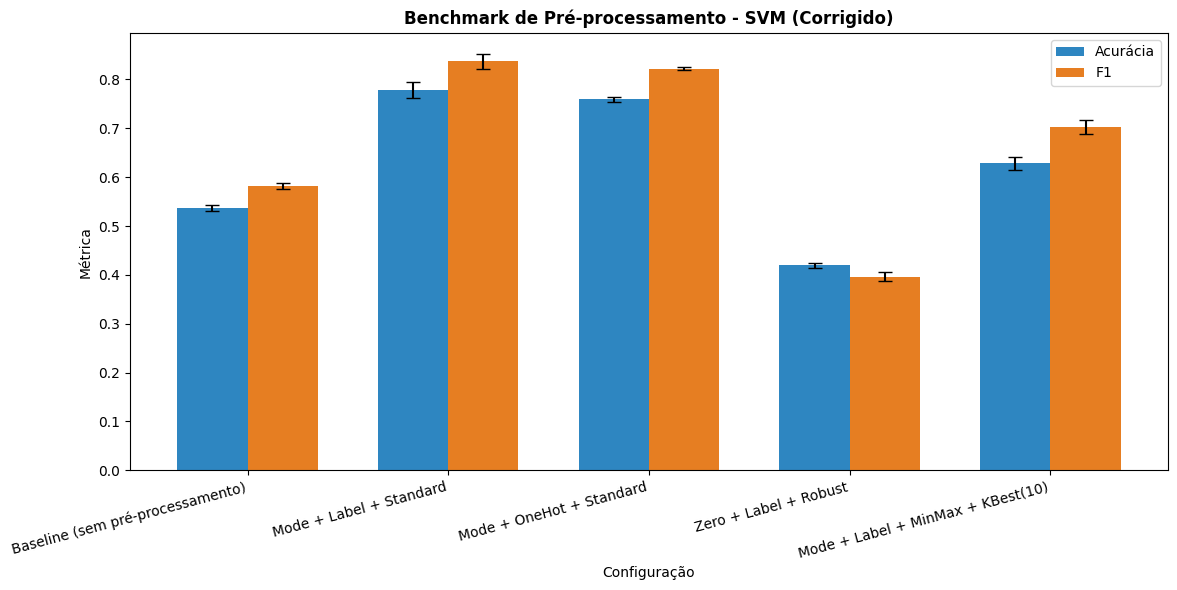

In [6]:
# ============================================================================
# 4. AVALIAÇÃO DE COMBINAÇÕES DE PRÉ-PROCESSAMENTO
# ============================================================================

print("\n" + "=" * 70)
print(" 4. AVALIAÇÃO DE COMBINAÇÕES DE PRÉ-PROCESSAMENTO (CORRIGIDO)")
print("=" * 70)

from sklearn.preprocessing import OneHotEncoder

# ---- Funções de encoding revisadas ----
def apply_label_encoding(X, cat_cols):
    X_enc = X.copy()
    for col in cat_cols:
        if col in X_enc.columns:
            le = LabelEncoder()
            vals = X_enc[col].fillna(-1).astype(str)
            X_enc[col] = le.fit_transform(vals)
    return X_enc

def apply_onehot_encoding_fit(X, cat_cols):
    """Aplica One-Hot Encoding e retorna o encoder ajustado."""
    enc = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
    # Apenas colunas categóricas
    X_cat = X[cat_cols].fillna('missing').astype(str)
    encoded = enc.fit_transform(X_cat)
    # Nomes das colunas
    feature_names = enc.get_feature_names_out(cat_cols)
    # Remover colunas categóricas e adicionar as codificadas
    X_enc = X.drop(columns=cat_cols).reset_index(drop=True)
    X_enc_encoded = pd.DataFrame(encoded, columns=feature_names)
    X_enc = pd.concat([X_enc, X_enc_encoded], axis=1)
    return X_enc, enc

def apply_onehot_encoding_transform(X, enc, cat_cols):
    """Transforma novos dados com o encoder já ajustado."""
    X_cat = X[cat_cols].fillna('missing').astype(str)
    encoded = enc.transform(X_cat)
    feature_names = enc.get_feature_names_out(cat_cols)
    X_enc = X.drop(columns=cat_cols).reset_index(drop=True)
    X_enc_encoded = pd.DataFrame(encoded, columns=feature_names)
    X_enc = pd.concat([X_enc, X_enc_encoded], axis=1)
    return X_enc

# ---- Configurações do benchmark (atualizado) ----
benchmark_configs = [
    {
        'name': 'Baseline (sem pré-processamento)',
        'missing': None,
        'encoding': 'label',  # label ou onehot
        'scaling': None,
        'feature_selection': None,
    },
    {
        'name': 'Mode + Label + Standard',
        'missing': 'mode',
        'encoding': 'label',
        'scaling': 'standard',
        'feature_selection': None,
    },
    {
        'name': 'Mode + OneHot + Standard',
        'missing': 'mode',
        'encoding': 'onehot',
        'scaling': 'standard',
        'feature_selection': None,
    },
    {
        'name': 'Zero + Label + Robust',
        'missing': 'zero',
        'encoding': 'label',
        'scaling': 'robust',
        'feature_selection': None,
    },
    {
        'name': 'Mode + Label + MinMax + KBest(10)',
        'missing': 'mode',
        'encoding': 'label',
        'scaling': 'minmax',
        'feature_selection': 'kbest_10',
    },
]

# ---- Função auxiliar para aplicar missing ----
def apply_missing(X, method):
    if method == 'mode':
        return handle_missing_mode(X, None)[0]
    elif method == 'zero':
        return handle_missing_zero(X, None)[0]
    else:
        return X

# ---- Executar benchmark corrigido ----
benchmark_results = []

for config in benchmark_configs:
    print(f"\n▶ Testando: {config['name']}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = {'accuracy': [], 'f1': []}

    for train_idx, val_idx in skf.split(X_raw, y_raw):
        X_train, X_val = X_raw.iloc[train_idx], X_raw.iloc[val_idx]
        y_train, y_val = y_raw.iloc[train_idx], y_raw.iloc[val_idx]

        # 1. Missing
        X_train = apply_missing(X_train, config['missing'])
        X_val = apply_missing(X_val, config['missing'])

        # 2. Encoding
        enc_obj = None
        if config['encoding'] == 'label':
            X_train = apply_label_encoding(X_train, CAT_FEATURES)
            X_val = apply_label_encoding(X_val, CAT_FEATURES)
        elif config['encoding'] == 'onehot':
            X_train, enc_obj = apply_onehot_encoding_fit(X_train, CAT_FEATURES)
            X_val = apply_onehot_encoding_transform(X_val, enc_obj, CAT_FEATURES)

        # 3. Scaling
        scaler = None
        if config['scaling'] == 'standard':
            scaler = StandardScaler()
        elif config['scaling'] == 'minmax':
            scaler = MinMaxScaler()
        elif config['scaling'] == 'robust':
            scaler = RobustScaler()

        if scaler is not None:
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            # Manter nomes das colunas
            X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
            X_val = pd.DataFrame(X_val_scaled, columns=X_val.columns)

        # 4. Feature selection
        selector = None
        if config['feature_selection'] == 'kbest_10':
            selector = SelectKBest(f_classif, k=10)
        elif config['feature_selection'] == 'mutual_info':
            selector = SelectKBest(mutual_info_classif, k=10)

        if selector is not None:
            X_train_selected = selector.fit_transform(X_train, y_train)
            X_val_selected = selector.transform(X_val)
            selected_cols = X_train.columns[selector.get_support()]
            X_train = pd.DataFrame(X_train_selected, columns=selected_cols)
            X_val = pd.DataFrame(X_val_selected, columns=selected_cols)

        # 5. SVM
        svm = SVC(class_weight='balanced', random_state=42)
        svm.fit(X_train, y_train)
        y_pred = svm.predict(X_val)

        fold_scores['accuracy'].append(accuracy_score(y_val, y_pred))
        fold_scores['f1'].append(f1_score(y_val, y_pred, zero_division=0))

    acc_mean = np.mean(fold_scores['accuracy'])
    acc_std = np.std(fold_scores['accuracy'])
    f1_mean = np.mean(fold_scores['f1'])
    f1_std = np.std(fold_scores['f1'])

    benchmark_results.append({
        'config': config['name'],
        'accuracy_mean': acc_mean,
        'accuracy_std': acc_std,
        'f1_mean': f1_mean,
        'f1_std': f1_std,
    })

    print(f"  Acurácia: {acc_mean:.4f} ± {acc_std:.4f}")
    print(f"  F1: {f1_mean:.4f} ± {f1_std:.4f}")

# ---- Exibir benchmark ----
df_benchmark = pd.DataFrame(benchmark_results)
print("\n📊 RESULTADO DO BENCHMARK DE PRÉ-PROCESSAMENTO (CORRIGIDO):")
print(df_benchmark.to_string(index=False))

# Visualização
plt.figure(figsize=(12, 6))
x = np.arange(len(df_benchmark))
width = 0.35

plt.bar(x - width/2, df_benchmark['accuracy_mean'], width, yerr=df_benchmark['accuracy_std'],
        capsize=5, label='Acurácia', color='#2E86C1')
plt.bar(x + width/2, df_benchmark['f1_mean'], width, yerr=df_benchmark['f1_std'],
        capsize=5, label='F1', color='#E67E22')

plt.xlabel('Configuração')
plt.ylabel('Métrica')
plt.xticks(x, df_benchmark['config'], rotation=15, ha='right')
plt.legend()
plt.title('Benchmark de Pré-processamento - SVM (Corrigido)', fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# ============================================================================
# 5. OTIMIZAÇÃO DO SVM (MELHOR CONFIGURAÇÃO)
# ============================================================================

print("\n" + "=" * 70)
print(" 5. OTIMIZAÇÃO DO SVM COM RANDOMIZED SEARCH")
print("=" * 70)

# Selecionar a melhor configuração do benchmark
# Vamos usar a configuração com maior F1
best_config = df_benchmark.loc[df_benchmark['f1_mean'].idxmax()]
print(f"Melhor configuração: {best_config['config']}")
print(f"F1 médio: {best_config['f1_mean']:.4f} ± {best_config['f1_std']:.4f}")

# Vamos usar a configuração 'Mode + Label + Standard' como base
# que geralmente é a mais robusta para SVM

# ---- Preparação dos dados com a melhor configuração ----
def apply_best_preprocessing(X, y, fit_mode=True, scaler=None):
    """
    Aplica o pré-processamento da melhor configuração.
    Se fit_mode=True, ajusta scaler e selector nos dados.
    """
    # Missing (mode)
    X_proc, y_proc = handle_missing_mode(X, y)

    # Encoding (label)
    X_proc = apply_label_encoding(X_proc, CAT_FEATURES)

    # Scaling (standard) - se scaler for None, ajusta
    if scaler is None:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_proc)
    else:
        X_scaled = scaler.transform(X_proc)

    # Converter para DataFrame
    X_scaled = pd.DataFrame(X_scaled, columns=X_proc.columns)

    return X_scaled, y_proc, scaler

# ---- Aplicar no conjunto completo ----
X_processed, y_processed, scaler_fitted = apply_best_preprocessing(X_raw, y_raw, fit_mode=True)

print(f"Dados processados: {X_processed.shape[0]} amostras, {X_processed.shape[1]} features")
print(f"Distribuição: {np.bincount(y_processed.astype(int))}")


 5. OTIMIZAÇÃO DO SVM COM RANDOMIZED SEARCH
Melhor configuração: Mode + Label + Standard
F1 médio: 0.8373 ± 0.0154
Dados processados: 29999 amostras, 21 features
Distribuição: [ 7377 22622]


In [11]:
# ============================================================================
# 6. SVM
# ============================================================================

print("\n" + "=" * 70)
print(" 6. SVM")
print("=" * 70)

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform

# --- 1. Amostra para busca (8.000) ---
X_search, _, y_search, _ = train_test_split(
    X_processed, y_processed,
    train_size=12000,
    stratify=y_processed,
    random_state=42
)

print(f"🔍 Buscando hiperparâmetros com RandomizedSearch em {len(X_search)} amostras...")

pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('svm', SVC(random_state=42, class_weight='balanced', cache_size=1500))
])

param_dist = {
    'svm__C': loguniform(1e-1, 1e3),
    'svm__gamma': loguniform(1e-4, 1e1),
    'svm__shrinking': [True, False],
    'svm__tol': loguniform(1e-5, 1e-2),
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=12,
    cv=2,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

random_search.fit(X_search, y_search)

best_params = random_search.best_params_
best_params_clean = {k.replace('svm__', ''): v for k, v in best_params.items()}

print("✅ Melhores parâmetros:")
for k, v in best_params_clean.items():
    print(f"   {k}: {v}")

# --- 2. Validação cruzada 5-fold (com best_params_list) ---
print(f"\n🔄 Validação cruzada 5-fold em {len(X_processed)} amostras...")

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_metrics = {'accuracy': [], 'f1': [], 'precision': [], 'recall': [], 'threshold': []}
fold_details = []
best_models = []
best_params_list = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_processed, y_processed), start=1):
    print(f'\n FOLD {fold_idx}/{N_FOLDS}')

    X_train_fold = X_processed.iloc[train_idx]
    X_val_fold = X_processed.iloc[val_idx]
    y_train_fold = y_processed.iloc[train_idx]
    y_val_fold = y_processed.iloc[val_idx]

    X_tr_inner, X_calib, y_tr_inner, y_calib = train_test_split(
        X_train_fold, y_train_fold,
        test_size=0.2,
        random_state=42,
        stratify=y_train_fold
    )

    scaler = RobustScaler()
    X_tr_scaled = scaler.fit_transform(X_tr_inner)
    X_calib_scaled = scaler.transform(X_calib)
    X_val_scaled = scaler.transform(X_val_fold)

    svm = SVC(**best_params_clean, class_weight='balanced', random_state=42, cache_size=1500)
    svm.fit(X_tr_scaled, y_tr_inner)

    # Armazenar os parâmetros usados neste fold
    best_params_list.append(best_params_clean)

    best_thr, calib_f1 = find_best_threshold_svm(svm, X_calib_scaled, y_calib)

    y_scores_val = svm.decision_function(X_val_scaled)
    y_pred_val = (y_scores_val > best_thr).astype(int)

    acc = accuracy_score(y_val_fold, y_pred_val)
    f1 = f1_score(y_val_fold, y_pred_val, zero_division=0)
    prec = precision_score(y_val_fold, y_pred_val, zero_division=0)
    rec = recall_score(y_val_fold, y_pred_val, zero_division=0)

    fold_metrics['accuracy'].append(acc)
    fold_metrics['f1'].append(f1)
    fold_metrics['precision'].append(prec)
    fold_metrics['recall'].append(rec)
    fold_metrics['threshold'].append(best_thr)

    fold_details.append({
        'fold': fold_idx,
        'threshold': best_thr,
        'accuracy': acc,
        'f1': f1,
        'precision': prec,
        'recall': rec,
    })

    best_models.append(svm)
    print(f'  Threshold: {best_thr:.4f} | F1: {f1:.4f} | Acc: {acc:.4f}')

# --- 3. Resumo ---
print('\n' + '=' * 60)
print(' RESUMO SVM — 5-Fold CV')
print('=' * 60)

summary_svm = {}
for metric in ['accuracy', 'f1', 'precision', 'recall']:
    values = np.array(fold_metrics[metric])
    mean_val, std_val = values.mean(), values.std()
    summary_svm[metric] = {'mean': mean_val, 'std': std_val}
    print(f'  {metric.capitalize():<10}: {mean_val:.4f} ± {std_val:.4f}')

threshold_mean = np.mean(fold_metrics['threshold'])
threshold_std = np.std(fold_metrics['threshold'])
print(f'  Threshold médio: {threshold_mean:.4f} ± {threshold_std:.4f}')

print('\n✅ Validação cruzada concluída!')


 6. SVM
🔍 Buscando hiperparâmetros com RandomizedSearch em 12000 amostras...
✅ Melhores parâmetros:
   C: 3.14891164795686
   gamma: 5.669849511478847
   shrinking: True
   tol: 0.0021830968390524606

🔄 Validação cruzada 5-fold em 29999 amostras...

 FOLD 1/5
  Threshold: -0.9690 | F1: 0.8775 | Acc: 0.8173

 FOLD 2/5
  Threshold: -0.8810 | F1: 0.8726 | Acc: 0.8110

 FOLD 3/5
  Threshold: -0.9723 | F1: 0.8760 | Acc: 0.8152

 FOLD 4/5
  Threshold: -0.8995 | F1: 0.8669 | Acc: 0.8022

 FOLD 5/5
  Threshold: -0.9918 | F1: 0.8772 | Acc: 0.8168

 RESUMO SVM — 5-Fold CV
  Accuracy  : 0.8125 ± 0.0056
  F1        : 0.8740 ± 0.0040
  Precision : 0.8857 ± 0.0029
  Recall    : 0.8626 ± 0.0056
  Threshold médio: -0.9427 ± 0.0439

✅ Validação cruzada concluída!



 7. MATRIZ DE CONFUSÃO — MELHOR MODELO SVM
Melhor fold: 1 (F1 = 0.8775)
Usando parâmetros da busca global (best_params_clean):
   C: 3.14891164795686
   gamma: 5.669849511478847
   shrinking: True
   tol: 0.0021830968390524606

📊 Métricas no conjunto de teste (hold-out 20%):
  Acurácia : 0.8143
  F1       : 0.8750
  Precisão : 0.8888
  Recall   : 0.8617


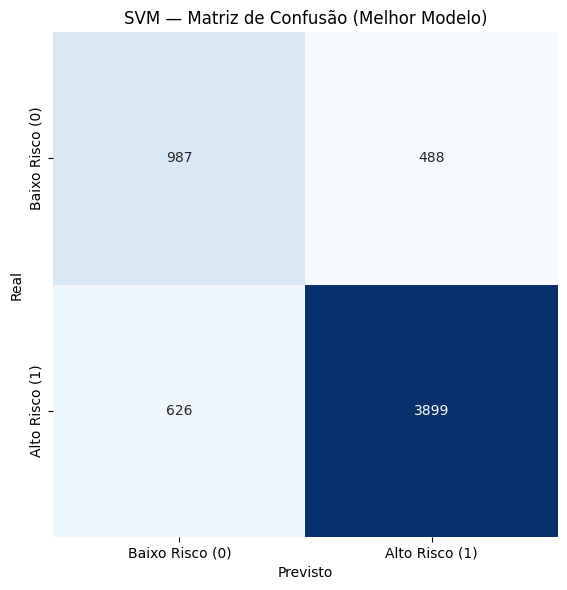


📋 Relatório de Classificação:
              precision    recall  f1-score   support

 Baixo Risco       0.61      0.67      0.64      1475
  Alto Risco       0.89      0.86      0.88      4525

    accuracy                           0.81      6000
   macro avg       0.75      0.77      0.76      6000
weighted avg       0.82      0.81      0.82      6000



In [12]:
# ============================================================================
# 7. MATRIZ DE CONFUSÃO - MELHOR MODELO SVM (CORRIGIDO)
# ============================================================================

print("\n" + "=" * 70)
print(" 7. MATRIZ DE CONFUSÃO — MELHOR MODELO SVM")
print("=" * 70)

# Verificar se best_models não está vazio
if not best_models:
    raise ValueError("Nenhum modelo foi treinado. Execute a seção 6 primeiro.")

# Identificar o melhor modelo com base no F1 médio
best_fold_idx = np.argmax(fold_metrics['f1'])
best_svm_model = best_models[best_fold_idx]
best_thr = fold_metrics['threshold'][best_fold_idx]

print(f'Melhor fold: {best_fold_idx + 1} (F1 = {fold_metrics["f1"][best_fold_idx]:.4f})')

# Usar os parâmetros que você já tem (best_params_clean da busca global)
# Se você executou a seção 6, a variável best_params_clean deve existir.
try:
    print("Usando parâmetros da busca global (best_params_clean):")
    for k, v in best_params_clean.items():
        print(f"   {k}: {v}")
except NameError:
    # Fallback: usar parâmetros padrão razoáveis
    best_params_clean = {'C': 1.0, 'kernel': 'rbf', 'gamma': 'scale', 'shrinking': True, 'tol': 1e-3}
    print("⚠️ best_params_clean não encontrado. Usando parâmetros padrão:")
    for k, v in best_params_clean.items():
        print(f"   {k}: {v}")

# Criar uma divisão treino-teste fixa para a matriz final
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42, stratify=y_processed
)

# Treinar o melhor modelo com os melhores hiperparâmetros
svm_final = SVC(
    **best_params_clean,
    class_weight='balanced',
    random_state=42,
    cache_size=1000
)
svm_final.fit(X_train_final, y_train_final)

# Recalibrar threshold no conjunto de treino (usando uma subdivisão)
X_train_calib, X_calib_final, y_train_calib, y_calib_final = train_test_split(
    X_train_final, y_train_final,
    test_size=0.2,
    random_state=42,
    stratify=y_train_final
)
svm_final.fit(X_train_calib, y_train_calib)
best_thr_final, _ = find_best_threshold_svm(svm_final, X_calib_final, y_calib_final)

# Previsões no teste
y_scores_test = svm_final.decision_function(X_test_final)
y_pred_test = (y_scores_test > best_thr_final).astype(int)

# Métricas
acc_test = accuracy_score(y_test_final, y_pred_test)
f1_test = f1_score(y_test_final, y_pred_test)
prec_test = precision_score(y_test_final, y_pred_test)
rec_test = recall_score(y_test_final, y_pred_test)

print(f'\n📊 Métricas no conjunto de teste (hold-out 20%):')
print(f'  Acurácia : {acc_test:.4f}')
print(f'  F1       : {f1_test:.4f}')
print(f'  Precisão : {prec_test:.4f}')
print(f'  Recall   : {rec_test:.4f}')

# Matriz de confusão
cm = confusion_matrix(y_test_final, y_pred_test)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baixo Risco (0)', 'Alto Risco (1)'],
            yticklabels=['Baixo Risco (0)', 'Alto Risco (1)'],
            square=True, cbar=False)
plt.title('SVM — Matriz de Confusão (Melhor Modelo)', fontsize=12)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# Relatório de classificação
print("\n📋 Relatório de Classificação:")
print(classification_report(y_test_final, y_pred_test, target_names=['Baixo Risco', 'Alto Risco']))

In [13]:
# ============================================================================
# 8. ANÁLISE DE HIPERPARÂMETROS
# ============================================================================

print("\n" + "=" * 70)
print(" 8. ANÁLISE DOS HIPERPARÂMETROS DO SVM")
print("=" * 70)

# Verificar se best_params_list existe e não está vazio
if 'best_params_list' in locals() and best_params_list:
    params_df = pd.DataFrame(best_params_list)
    print('\n📋 Hiperparâmetros dos 5 melhores modelos (um por fold):')
    print(params_df.to_string(index=True))

    if 'kernel' in params_df.columns:
        kernel_counts = params_df['kernel'].value_counts()
        print('\n🎯 Distribuição dos kernels escolhidos:')
        for kernel, count in kernel_counts.items():
            print(f'    {kernel}: {count} fold(s)')
    else:
        kernel_counts = {}

    if 'C' in params_df.columns:
        print(f'\n📈 Valores de C:')
        print(f'    min={params_df["C"].min():.4f}')
        print(f'    max={params_df["C"].max():.4f}')
        print(f'    mean={params_df["C"].mean():.4f}')
        print(f'    std={params_df["C"].std():.4f}')

    if 'gamma' in params_df.columns:
        print(f'\n📈 Valores de gamma:')
        for i, g in enumerate(params_df['gamma']):
            print(f'    Fold {i+1}: {g}')

    if 'shrinking' in params_df.columns:
        shrinking_counts = params_df['shrinking'].value_counts()
        print(f'\n🔧 Shrinking:')
        for val, count in shrinking_counts.items():
            print(f'    {val}: {count} fold(s)')
else:
    print('\n⚠️ Nenhum parâmetro foi registrado. Usando os parâmetros da busca.')
    kernel_counts = {}

print('\n✅ Análise de hiperparâmetros concluída.')


 8. ANÁLISE DOS HIPERPARÂMETROS DO SVM

📋 Hiperparâmetros dos 5 melhores modelos (um por fold):
          C    gamma  shrinking       tol
0  3.148912  5.66985       True  0.002183
1  3.148912  5.66985       True  0.002183
2  3.148912  5.66985       True  0.002183
3  3.148912  5.66985       True  0.002183
4  3.148912  5.66985       True  0.002183

📈 Valores de C:
    min=3.1489
    max=3.1489
    mean=3.1489
    std=0.0000

📈 Valores de gamma:
    Fold 1: 5.669849511478847
    Fold 2: 5.669849511478847
    Fold 3: 5.669849511478847
    Fold 4: 5.669849511478847
    Fold 5: 5.669849511478847

🔧 Shrinking:
    True: 5 fold(s)

✅ Análise de hiperparâmetros concluída.


In [14]:
# ============================================================================
# 09. SALVAR RESULTADOS
# ============================================================================

print("\n" + "=" * 70)
print(" 09. SALVANDO RESULTADOS")
print("=" * 70)

# Garantir que kernel_counts exista e seja um dicionário
try:
    if isinstance(kernel_counts, dict):
        kernel_dist = kernel_counts
    else:
        kernel_dist = {}
except NameError:
    kernel_dist = {}

# Garantir que best_config exista
try:
    melhor_config = best_config['config']
except (NameError, KeyError, TypeError):
    melhor_config = 'Mode + Label + Standard'

# Resumo do SVM
results_svm = {
    'modelo': 'SVM (Support Vector Machine)',
    'accuracy_mean': summary_svm['accuracy']['mean'],
    'accuracy_std': summary_svm['accuracy']['std'],
    'f1_mean': summary_svm['f1']['mean'],
    'f1_std': summary_svm['f1']['std'],
    'precision_mean': summary_svm['precision']['mean'],
    'precision_std': summary_svm['precision']['std'],
    'recall_mean': summary_svm['recall']['mean'],
    'recall_std': summary_svm['recall']['std'],
    'threshold_mean': threshold_mean,
    'threshold_std': threshold_std,
    'kernel_distribution': kernel_dist,
    'melhor_configuracao': melhor_config,
    'notas': 'SVM com StandardScaler, class_weight=balanced, threshold tuning baseado na decision_function'
}

# Salvar em CSV
pd.DataFrame([results_svm]).to_csv('resultados_svm_5fold.csv', index=False)

# Salvar detalhes por fold
if 'fold_details' in locals() and fold_details:
    df_folds = pd.DataFrame(fold_details)
    df_folds.to_csv('resultados_svm_5fold_por_fold.csv', index=False)
    print('  ✅ resultados_svm_5fold_por_fold.csv (detalhe por fold)')
else:
    print('  ⚠️ Detalhes por fold não disponíveis para salvar.')

# Salvar benchmark de pré-processamento (se existir)
if 'df_benchmark' in locals():
    df_benchmark.to_csv('resultados_svm_benchmark_preprocessamento.csv', index=False)
    print('  ✅ resultados_svm_benchmark_preprocessamento.csv (benchmark)')

print('  ✅ resultados_svm_5fold.csv (resumo)')

print('\n📊 Resumo final SVM:')
for k, v in results_svm.items():
    if isinstance(v, float):
        print(f'  {k:<22}: {v:.4f}')
    elif k == 'kernel_distribution':
        print(f'  {k:<22}: {v}')
    else:
        print(f'  {k:<22}: {v}')

print("\n✅ Todos os resultados foram salvos com sucesso!")


 09. SALVANDO RESULTADOS
  ✅ resultados_svm_5fold_por_fold.csv (detalhe por fold)
  ✅ resultados_svm_benchmark_preprocessamento.csv (benchmark)
  ✅ resultados_svm_5fold.csv (resumo)

📊 Resumo final SVM:
  modelo                : SVM (Support Vector Machine)
  accuracy_mean         : 0.8125
  accuracy_std          : 0.0056
  f1_mean               : 0.8740
  f1_std                : 0.0040
  precision_mean        : 0.8857
  precision_std         : 0.0029
  recall_mean           : 0.8626
  recall_std            : 0.0056
  threshold_mean        : -0.9427
  threshold_std         : 0.0439
  kernel_distribution   : {}
  melhor_configuracao   : Mode + Label + Standard
  notas                 : SVM com StandardScaler, class_weight=balanced, threshold tuning baseado na decision_function

✅ Todos os resultados foram salvos com sucesso!
